# 9 &middot; Contact: Dropping an Elastic Block on the Floor

Inertia + gravity + contact together: an elastic block is **dropped** onto a flat
floor and bounces. We step it with Backward Euler and watch the three energies
trade off &mdash; gravity builds **kinetic** energy on the way down; impact spikes
the **contact** penalty and stores **elastic** energy; the rebound reverses it.

Each step solves one minimization with Newton,

$$
x_{n+1} = \arg\min_x\; \tfrac{1}{2h^2}\lVert x - \tilde{x}\rVert_M^2
        + E_{\text{elastic}}(x) + E_{\text{gravity}}(x) + E_{\text{floor}}(x),
$$

where $\tilde{x} = x_n + h\,v_n$ is the momentum prediction and the floor term is a
penalty spring on any vertex below the plane.

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
from simkit.solvers import newton_solver
import utils

## Block, floor, and one Backward-Euler simulator

`DropSim` composes four terms from `utils` &mdash; the **elastic** material, the
**gravity** potential, a **floor** penalty (a spring on any vertex that drops
below the plane through `[0, FLOOR_Y]` with upward normal `[0, 1]`), and the
backward-Euler **inertia** &mdash; and sums them one per line, exactly as the
Newton solver wants. Each `step()` refreshes the inertia prediction $\tilde{x} =
x_n + h\,v_n$, Newton-solves for $x_{n+1}$, and updates the velocity.

In [2]:
FLOOR_Y = -0.6

class DropSim:
    """Drop an elastic block on a floor: elastic + gravity + floor + inertia,
    stepped with Backward Euler and Newton."""

    def __init__(self, X, T, h=0.01):
        self.p       = utils.precompute(X, T, ym=1e5, pr=0.4, rho=1e3, gravity=-9.8)
        self.psi     = utils.make_material("Neo-Hookean")
        self.gravity = utils.Gravity(self.p.f_g)
        self.floor   = utils.PlaneContact(1e5, [0.0, FLOOR_Y], [0.0, 1.0], self.p.M_n, self.p.dim)
        self.inertia = utils.Inertia(self.p.M, h)
        self.x = X.reshape(-1, 1).astype(float)
        self.v = np.zeros_like(self.x)

    def energy(self, x):
        E_elastic = self.psi.energy(x, self.p)
        E_gravity = self.gravity.energy(x)
        E_floor   = self.floor.energy(x)
        E_inertia = self.inertia.energy(x)
        return E_elastic + E_gravity + E_floor + E_inertia

    def gradient(self, x):
        g_elastic = self.psi.gradient(x, self.p)
        g_gravity = self.gravity.gradient(x)
        g_floor   = self.floor.gradient(x)
        g_inertia = self.inertia.gradient(x)
        return g_elastic + g_gravity + g_floor + g_inertia

    def hessian(self, x):
        H_elastic = self.psi.hessian(x, self.p)
        H_floor   = self.floor.hessian(x)
        H_inertia = self.inertia.hessian(x)
        return H_elastic + H_floor + H_inertia

    def step(self):
        self.inertia.update(self.x, self.v)
        x_new = newton_solver(self.x, self.energy, self.gradient, self.hessian,
                              max_iter=8, do_line_search=True)
        self.v = (x_new - self.x) / self.inertia.h
        self.x = x_new
        return self.x.reshape(self.p.n, self.p.dim)

## Run the drop, recording elastic / kinetic / contact energy each step

We start the block up high and step it 130 times. At each step we record the
**elastic** energy (the material term), the **kinetic** energy
$\tfrac{1}{2}v^\top M v$, and the **contact** energy (the floor penalty).

impact near t = 0.55s


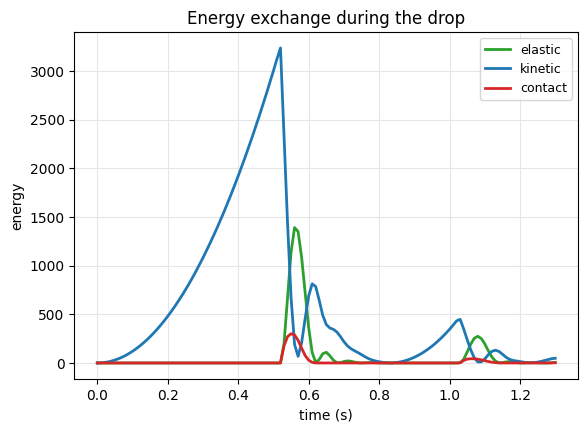

In [3]:
X, T = utils.triangulated_grid(nx=10, ny=8, width=0.5, height=0.5)
X[:, 1] += 1.0                                       # start up high

sim = DropSim(X, T, h=0.01)
states, t_axis = [X.copy()], [0.0]
E_el, E_kin, E_con = [0.0], [0.0], [0.0]
for s in range(130):
    U_next = sim.step()
    E_el.append(sim.psi.energy(sim.x, sim.p))
    E_kin.append(0.5 * float((sim.v.T @ (sim.p.M @ sim.v))[0, 0]))
    E_con.append(sim.floor.energy(sim.x))
    states.append(U_next.copy())
    t_axis.append((s + 1) * sim.inertia.h)

t_axis = np.array(t_axis)
series = {"elastic": np.array(E_el), "kinetic": np.array(E_kin), "contact": np.array(E_con)}
print(f"impact near t = {t_axis[int(np.argmax(E_con))]:.2f}s")

utils.line_plot(t_axis, series, xlabel="time (s)", ylabel="energy",
                colors=utils.ENERGY_COLORS, title="Energy exchange during the drop")
plt.show()

In [4]:
fig, anim = utils.animate_dynamics(states, T, t_axis, series, lims=((-1.0, 1.0), (-0.8, 1.4)),
    xlabel="time (s)", ylabel="energy", colors=utils.ENERGY_COLORS, floor_y=FLOOR_Y,
    scene_title="elastic block dropping on the floor",
    title="elastic / kinetic / contact energy", fps=25)
utils.show_video(fig, anim, "media/09_contact_plane.mp4", fps=25)

### Takeaways
* Gravity &rarr; **kinetic** on the way down; impact &rarr; **elastic** +
  **contact**; rebound reverses it.
* The **contact** penalty spikes exactly at impact.
* Penalty contact + Backward Euler lose a little energy each bounce (the spring is
  springy, BE damps), so the block doesn't bounce back to full height.